<a href="https://colab.research.google.com/github/dmitrykosintsev/lm-zoomcamp/blob/main/08-deeplearning-with-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unit 8. Deep Learning using PyTorch

### 8.1 Introduction to PyTorch

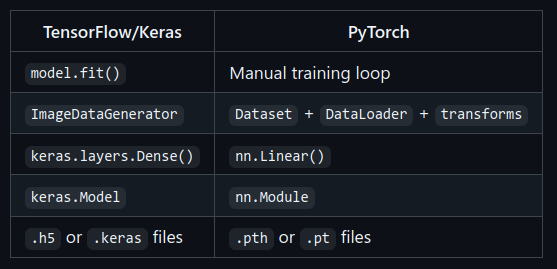

### 8.2 Image loading

In [1]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 28.87 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (3783/3783), done.


In [2]:
# Import necessary libraries
import os
import torch
import torch.optim as optim
import torch.nn as nn
import torchvision.models as models
import numpy as np

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

In [3]:
# Opening the image
img = Image.open('clothing-dataset-small/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')

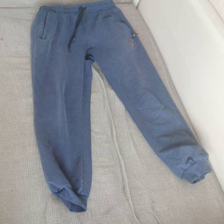

In [4]:
# Show and resize
img.resize((224,224))

In [5]:
# Making the image a numpy array
x = np.array(img.resize((224,224)))

In [6]:
# Checking the shape of the array
x.shape

(224, 224, 3)

### 8.3 Pre-trained models

In [7]:
# Load pre-trained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval() # Using this model only for evaluation of making predictions

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
# Preprocessing for MobileNetV2 - can be found on the internet in recommendations
preprocess = transforms.Compose([
    transforms.Resize(256), # Resize
    transforms.CenterCrop(224), # Central crop
    transforms.ToTensor(), # Turn it into tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalise data
])

In [9]:
# Use the function to prepare the image for the neural network
x = preprocess(img)

In [10]:
# Turn the image into a batch
batch_t = torch.unsqueeze(x, 0)

In [11]:
batch_t.shape

torch.Size([1, 3, 224, 224])

In [12]:
x.shape

torch.Size([3, 224, 224])

In [13]:
# Making a prediction
with torch.no_grad(): # No_grad - evaluation only
  output = model(batch_t)

# We now have a prediction for each class
output.shape

torch.Size([1, 1000])

In [14]:
# Get top predictions
_, indices = torch.sort(output, descending=True)

indices

tensor([[608, 834, 474, 841, 689, 824, 501, 885, 906, 869, 601, 911, 775, 735,
         457, 655, 697, 578, 610, 434, 797, 411, 399, 452, 842, 568, 431, 617,
         516, 678, 591, 414, 796, 570, 840, 523, 793, 630, 636, 894, 903, 464,
         638, 502, 658, 614, 465, 588, 830, 515, 589, 691, 749, 808, 435, 529,
         780, 606, 806, 728, 837, 672, 887, 459, 643, 615, 702, 552, 480, 514,
         597, 777, 774, 512, 600, 823, 731, 490, 680, 790, 473, 419, 794, 715,
         772, 389, 602, 914, 451, 233, 667, 223, 652, 639, 750, 836, 831, 400,
         520, 676, 897, 876, 237, 770, 669, 585, 838, 748, 977, 177, 153, 559,
         395, 443, 487, 416, 461, 785, 982, 258, 172, 882, 257, 872, 456, 477,
         999, 801, 587, 169, 183, 171, 713, 499, 195, 741, 358, 584, 182, 463,
         250, 151, 700, 558, 170,  34, 447, 936, 557, 679, 224, 433, 543, 259,
         178, 222, 771, 879, 445, 513, 683, 627, 753, 843, 462, 765, 202, 197,
         173, 861, 265, 246, 792, 192, 811, 646, 256

In [15]:
# Download names of classes
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O imagenet_classes.txt

# Load ImageNet class names
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Get top 5 predictions
top5_indices = indices[0, :5].tolist()
top5_classes = [categories[i] for i in top5_indices]

print("Top 5 predictions:")
for i, class_name in enumerate(top5_classes):
    print(f"{i+1}: {class_name}")

--2025-12-03 15:17:55--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0.001s  

2025-12-03 15:17:55 (16.1 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]

Top 5 predictions:
1: jean
2: suit
3: cardigan
4: sweatshirt
5: overskirt


### 8.4 Convolutional neural networks

Convolutional Neural Networks (CNNs) are specialized neural networks for processing grid-like data such as images.

Key Components:

    Convolutional Layer: Extracts features using filters
        Applies filters (e.g., 3×3, 5×5) to detect patterns
        Creates feature maps (one per filter)
        Detects edges, textures, shapes

    ReLU Activation: Introduces non-linearity
        f(x) = max(0, x)
        Sets negative values to 0
        Helps network learn complex patterns

    Pooling Layer: Down-samples feature maps
        Reduces spatial dimensions
        Max pooling: takes maximum value in a region
        Makes features more robust to small translations

    Fully Connected (Dense) Layer: Final classification
        Flattens 2D feature maps to 1D vector
        Connects to output classes

CNN Workflow:

`Input Image → Conv + ReLU → Pooling → Conv + ReLU → Pooling → Flatten → Dense → Output`

### 8.5 Transfer learning

Approach:

    Load pre-trained model (feature extractor)
    Remove original classification head
    Freeze convolutional layers
    Add custom layers for our task
    Train only the new layers


In [16]:
class ClothingDataset(Dataset): # Create a dataset object
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir # Where it lives
        self.transform = transform
        self.image_paths = []
        self.labels = [] # What kind of labels
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes: # Go through files, open them and apply some transformations
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
# Specify our transformations
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [22]:
# Create dataloaders
train_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [18]:
# Creating a class to build a model
class ClothingClassifierMobileNet(nn.Module):
    # Creating the model
    def __init__(self, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    # In which order and how layers should be applied
    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

In [23]:
# Predictions using untrained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Running on GPU

model = ClothingClassifierMobileNet(num_classes=10)
model.to(device)

ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [24]:
# Training a model using optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [30]:
# Implementing training loop as a function
num_epochs = 10

def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

It's a lower-level framework, that's why we need to implement some of these things like calculating accuracy on validation.

The line **optimizer.zero_grad()** is crucial in the training loop.

In PyTorch, gradients are accumulated by default. This means that if you don't zero the gradients before calculating the gradients for the current batch, the gradients from the previous batch will be added to the gradients of the current batch. This would lead to incorrect updates to your model's parameters.

By calling **optimizer.zero_grad()**, you clear out the old gradients, ensuring that the gradients calculated during the loss.backward() call are only based on the current batch of data. This is essential for the optimizer to take the correct step during optimizer.step().

model.train() and model.eval() are needed to manage the behavior of certain layers during training and evaluation.

**model.train()** sets the model to training mode. In training mode, layers like Dropout and BatchNorm behave differently. Dropout layers are active (randomly dropping neurons), and BatchNorm layers update their running statistics (mean and variance) based on the current batch.

**model.eval()** sets the model to evaluation mode. In evaluation mode, Dropout layers are inactive (they pass through all neurons), and BatchNorm layers use their accumulated running statistics instead of the current batch statistics. This ensures consistent behavior during inference and prevents randomness from affecting the evaluation results.

### 8.6 Tuning the Learning Rate

The learning rate controls how much to update model weights during training. It's one of the most important hyperparameters.

Analogy: Reading speed

    Too fast: Skip details, poor understanding (may not converge)
    Too slow: Never finish the book (training takes too long)
    Just right: Good comprehension and efficiency

Experimentation approach:

    Try multiple values: [0.0001, 0.001, 0.01, 0.1]
    Train for a few epochs each
    Compare validation accuracy
    Choose the rate with best performance and smallest train/val gap


In [25]:
# Function to make a model
def make_model(learning_rate=0.01):
    model = ClothingClassifierMobileNet(num_classes=10)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
# Use various learning rates to see which one is the best
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f'\n=== Learning Rate: {lr} ===')
    model, optimizer = make_model(learning_rate=lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Learning Rate: 0.0001 ===
Epoch 1/10
  Train Loss: 1.9996, Train Acc: 0.3142
  Val Loss: 1.7818, Val Acc: 0.3988
Epoch 2/10
  Train Loss: 1.6389, Train Acc: 0.4778
  Val Loss: 1.4878, Val Acc: 0.5279
Epoch 3/10
  Train Loss: 1.4000, Train Acc: 0.5792
  Val Loss: 1.2994, Val Acc: 0.5865
Epoch 4/10
  Train Loss: 1.2432, Train Acc: 0.6265
  Val Loss: 1.1655, Val Acc: 0.6481
Epoch 5/10
  Train Loss: 1.1266, Train Acc: 0.6835
  Val Loss: 1.0683, Val Acc: 0.6745
Epoch 6/10
  Train Loss: 1.0341, Train Acc: 0.7132
  Val Loss: 0.9962, Val Acc: 0.7038
Epoch 7/10
  Train Loss: 0.9665, Train Acc: 0.7321
  Val Loss: 0.9296, Val Acc: 0.7625
Epoch 8/10
  Train Loss: 0.9009, Train Acc: 0.7591
  Val Loss: 0.8832, Val Acc: 0.7566
Epoch 9/10
  Train Loss: 0.8579, Train Acc: 0.7699
  Val Loss: 0.8498, Val Acc: 0.7507
Epoch 10/10
  Train Loss: 0.8175, Train Acc: 0.7751
  Val Loss: 0.8202, Val Acc: 0.7478

=== Learning Rate: 0.001 ===
Epoch 1/10
  Train Loss: 1.3184, Train Acc: 0.5919
  Val Loss: 0.896

### 8.7 Checkpointing

Checkpointing saves the model during training to:

    Keep the best performing model
    Resume training if interrupted
    Avoid losing progress


In [ ]:
def train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    # exising code
    # Checkpoint the model if validation accuracy improved
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        checkpoint_path = f'mobilenet_v2_{epoch+1:02d}_{val_acc:.3f}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f'Checkpoint saved: {checkpoint_path}')

### 8.8 Adding Inner Layers

In [26]:
# We can add intermediate dense layers between feature extraction and output:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [27]:
def make_model(
    learning_rate=0.001,
    size_inner=100
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [31]:
# Checking various sizes
for size_inner in [1000, 500, 100]:
    print(f'\n=== Size inner: {size_inner} ===')
    model, optimizer = make_model(learning_rate=0.001, size_inner=size_inner)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Size inner: 1000 ===


KeyboardInterrupt: 

In [32]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        # If it is better, save val_acc
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            checkpoint_path = f'clothing_v4_{epoch+1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

In [33]:
size_inner = 100
learning_rate = 0.001

model, optimizer = make_model(
    learning_rate=0.001,
    size_inner=size_inner
)

train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/10
  Train Loss: 1.2760, Train Acc: 0.5903
  Val Loss: 0.8325, Val Acc: 0.7155
Checkpoint saved: clothing_v4_01_0.716.pth
Epoch 2/10
  Train Loss: 0.7383, Train Acc: 0.7526
  Val Loss: 0.7738, Val Acc: 0.7067
Epoch 3/10
  Train Loss: 0.6059, Train Acc: 0.7976
  Val Loss: 0.5618, Val Acc: 0.7947
Checkpoint saved: clothing_v4_03_0.795.pth
Epoch 4/10
  Train Loss: 0.5402, Train Acc: 0.8171
  Val Loss: 0.5875, Val Acc: 0.7889
Epoch 5/10
  Train Loss: 0.4810, Train Acc: 0.8390
  Val Loss: 0.5364, Val Acc: 0.8270
Checkpoint saved: clothing_v4_05_0.827.pth
Epoch 6/10
  Train Loss: 0.4189, Train Acc: 0.8579
  Val Loss: 0.5312, Val Acc: 0.8094
Epoch 7/10
  Train Loss: 0.3974, Train Acc: 0.8680
  Val Loss: 0.5556, Val Acc: 0.8035
Epoch 8/10
  Train Loss: 0.4115, Train Acc: 0.8559
  Val Loss: 0.5883, Val Acc: 0.7801
Epoch 9/10
  Train Loss: 0.3780, Train Acc: 0.8657
  Val Loss: 0.5890, Val Acc: 0.8152
Epoch 10/10
  Train Loss: 0.3203, Train Acc: 0.8928
  Val Loss: 0.5590, Val Acc: 0.8035


### 8.9 Dropout Regularization
Dropout randomly drops neurons during training to prevent overfitting.

How it works:

    Training: randomly set fraction of activations to 0
    Inference: use all neurons (dropout disabled automatically)
    Creates ensemble effect

Benefits:

    Prevents relying on specific features
    Forces learning robust patterns
    Reduces overfitting


In [34]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))

        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

# Updating our model
def make_model(
        learning_rate=0.01,
        size_inner=100,
        droprate=0.2,
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner,
        droprate=droprate,
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [35]:
num_epochs = 50 # Need many iterations

for droprate in [0.2]: #[0.1, 0.2, 0.5, 0.7]:
  print('droprate =', droprate)

  model, optimizer = make_model(
      learning_rate=0.001,
      size_inner=100,
      droprate=droprate
  )

  train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

droprate = 0.2
Epoch 1/10
  Train Loss: 1.3190, Train Acc: 0.5691
  Val Loss: 0.8825, Val Acc: 0.7214
Checkpoint saved: clothing_v4_01_0.721.pth
Epoch 2/10
  Train Loss: 0.7935, Train Acc: 0.7379
  Val Loss: 0.6874, Val Acc: 0.7449
Checkpoint saved: clothing_v4_02_0.745.pth
Epoch 3/10
  Train Loss: 0.6676, Train Acc: 0.7686
  Val Loss: 0.5898, Val Acc: 0.7977
Checkpoint saved: clothing_v4_03_0.798.pth
Epoch 4/10
  Train Loss: 0.5906, Train Acc: 0.8074
  Val Loss: 0.5656, Val Acc: 0.8152
Checkpoint saved: clothing_v4_04_0.815.pth
Epoch 5/10
  Train Loss: 0.5381, Train Acc: 0.8152
  Val Loss: 0.6102, Val Acc: 0.7801
Epoch 6/10
  Train Loss: 0.4852, Train Acc: 0.8341
  Val Loss: 0.5506, Val Acc: 0.7977
Epoch 7/10
  Train Loss: 0.4801, Train Acc: 0.8338
  Val Loss: 0.5444, Val Acc: 0.8035
Epoch 8/10
  Train Loss: 0.4228, Train Acc: 0.8605
  Val Loss: 0.5908, Val Acc: 0.7889
Epoch 9/10
  Train Loss: 0.4363, Train Acc: 0.8455
  Val Loss: 0.5139, Val Acc: 0.8182
Checkpoint saved: clothing_v4_

### 8.10 Data augmentation
Data Augmentation artificially increases dataset size by applying random transformations to training images.

Common transformations:

    Rotation
    Horizontal/vertical flipping
    Zooming (random cropping)
    Shifting
    Shearing

Important rules:

    ✅ Apply ONLY to training data
    ❌ Never augment validation/test data


In [36]:
# Training transforms WITH augmentation
train_transforms = transforms.Compose([
    transforms.RandomRotation(10),           # Rotate up to 10 degrees
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # Zoom
    transforms.RandomHorizontalFlip(),       # Horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation transforms - NO augmentation, same as before
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

When to use augmentation:

    Small datasets
    Risk of overfitting
    Images can appear in different orientations

Tips:

    Choose augmentations that make sense for your data
    Too much augmentation can hurt performance
    Usually requires longer training (more epochs)
    If no improvement after ~20 epochs, don't use it


### 8.11 Using the Trained Model

In [39]:
# Import trained model
import glob

# Find best checkpoint
list_of_files = glob.glob('clothing_v4_*.pth')
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Loading model from: {latest_file}")

# Load model
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.2, num_classes=10)
model.load_state_dict(torch.load(latest_file))
model.to(device)

Loading model from: clothing_v4_09_0.818.pth


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [41]:
x = val_transforms(img)
batch_t = torch.unsqueeze(x, 0).to(device)

with torch.no_grad():
    output = model(batch_t)

In [43]:
classes = ['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']

In [44]:
dict(zip(classes, output[0].to('cpu')))

{'dress': tensor(0.8121),
 'hat': tensor(-0.0914),
 'longsleeve': tensor(1.6313),
 'outwear': tensor(-1.6571),
 'pants': tensor(-0.6248),
 'shirt': tensor(-1.0095),
 'shoes': tensor(-1.3385),
 'shorts': tensor(-1.2913),
 'skirt': tensor(-0.1007),
 't-shirt': tensor(1.5884)}

### 8.12 Exporting to ONNX

In [45]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 118.7 MB/s eta 0:00:00


In [ ]:
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
onnx_path = "clothing_classifier_mobilenet_v2.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)